# <p><center style="font-family:newtimeroman;font-size:180%;">Generative AI Chatbot for Alzheimer Disease</center></p>
# <p><center style="font-family:newtimeroman;font-size:180%;">Leader</center></p>
## Steps:

| Step |Description                                     |
|------|------------------------------------------------|
|0|[Introduction](#0)|
| 1    |[Import Libraries](#1)                          |
| 2    |[Read Data](#2)                                 |    
|3   |[Data Spliting](#3)|
|4|[Helper Function for GPT-2](#4)|
|5|[Training GPT-2](#5)|
|6|[Evaluation GPT-2 ](#6)|
|7|[Generation Using Custom GPT-2](#7)

**<a id="0"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Introduction </p>
<a class="btn" href="#home">Tabel of Contents</a>

#### Generative AI Chatbot for Alzheimer Disease
This notebook builds PreTrained Transformer GPT-2 in TensorFlow.

It serves to understand how each part of the Transformer works and how they all fit together.

The Transformer is then tested on a simple seq2seq task : Generative AI Chatbot for Alzheimer Disease.

**<a id="1"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Import Libraries </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [1]:
from transformers import (TextDataset, DataCollatorForLanguageModeling,GPT2Tokenizer,
                          GPT2LMHeadModel,Trainer, TrainingArguments)
import os
import transformers
import pandas as pd
import matplotlib.pyplot as plt
import wandb
wandb.init(mode="disabled")
import warnings
warnings.filterwarnings('ignore')

2024-05-17 02:27:38.543516: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-17 02:27:38.543618: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-17 02:27:38.673182: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


**<a id="2"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Read Data </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [2]:
data=pd.read_csv('/kaggle/input/alzhimer-chat-leader/full_Chat_data.csv',usecols=[1,2])
data.sample(5)

,Questions,Answers
2351,How does outdoor exposure and nature walks con...,Outdoor exposure and nature walks enhance well...
11292,Are there gender differences in the relationsh...,Research suggests that smoking may pose a high...
21396,How does Alzheimer's disease affect a person's...,Alzheimer's disease can disrupt the perception...
7825,What are the potential consequences of clottin...,Clotting issues in Alzheimer's patients can le...
3112,Can sugar consumption contribute to disruption...,Excessive sugar intake may contribute to disru...


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Questions  25173 non-null  object
 1   Answers    25154 non-null  object
dtypes: object(2)
memory usage: 393.5+ KB


**<a id="3"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Data Spliting </p>
<a class="btn" href="#home">Tabel of Contents</a>

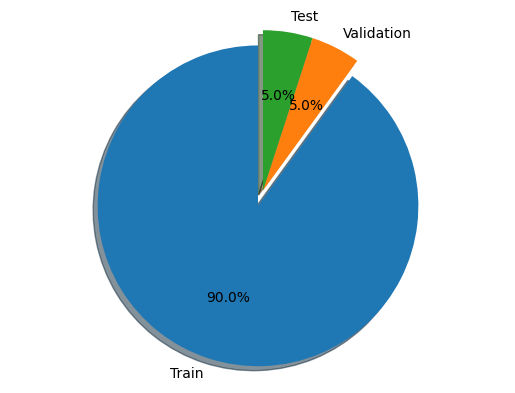

In [4]:
# shuffle the data
data = data.sample(frac=1).reset_index(drop=True)

# split the data into train, validation, and test sets
train_size = int(len(data) * 0.9)
val_size = int(len(data) * 0.05)
test_size = int(len(data) * 0.05)

train_df = data[:train_size]
val_df = data[train_size:train_size+val_size]
test_df = data[train_size+val_size:]

# display the data sets representations using a pie chart just to see the distribution of the data
labels = 'Train', 'Validation', 'Test'
sizes = [len(train_df), len(val_df), len(test_df)]
explode = (0.1, 0, 0)
fig1, ax1 = plt.subplots()
ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', shadow=True, startangle=90)
ax1.axis('equal')
plt.show()

In [5]:
train_df.to_csv('/kaggle/working/X_train.csv')
test_df.to_csv('/kaggle/working/X_test.csv')
val_df.to_csv('/kaggle/working/X_val.csv')

**<a id="4"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Helper Function for GPT-2 </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [6]:
def load_dataset(file_path, tokenizer, block_size = 1024):
    dataset_train = TextDataset(
        tokenizer = tokenizer,
        file_path = file_path+'X_train.csv',
        block_size = block_size,
    )
    dataset_test = TextDataset(
        tokenizer = tokenizer,
        file_path = file_path+'X_test.csv',
        block_size = block_size,
    )
    dataset_val = TextDataset(
        tokenizer = tokenizer,
        file_path = file_path+'X_val.csv',
        block_size = block_size,
    )
    return dataset_train,dataset_test,dataset_val

In [7]:
def load_data_collator(tokenizer, mlm = False):
    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer, 
        mlm=mlm,
    )
    return data_collator

In [8]:
def train(train_file_path, model_name, output_dir, overwrite_output_dir,
          per_device_train_batch_size, per_device_val_batch_size, num_train_epochs):
    tokenizer = GPT2Tokenizer.from_pretrained(model_name)

    # Load datasets
    train_dataset, test_dataset, val_dataset = load_dataset(train_file_path, tokenizer)

    # Load data collator
    data_collator = load_data_collator(tokenizer)

    # Save tokenizer
    tokenizer.save_pretrained(output_dir)

    # Load or initialize model
    model = GPT2LMHeadModel.from_pretrained(model_name)

    # Save model
    model.save_pretrained(output_dir)

    training_args = TrainingArguments(
        output_dir=output_dir,
        overwrite_output_dir=overwrite_output_dir,
        num_train_epochs=num_train_epochs,
        per_device_train_batch_size=per_device_train_batch_size,
        per_device_eval_batch_size=per_device_val_batch_size,
        evaluation_strategy="epoch",
        logging_dir="./logs",
        logging_steps=100,  # Log every 100 steps
        save_steps=500,  # Save checkpoint every 500 steps
        logging_first_step=True,
        save_total_limit=2,
          learning_rate=2e-4,
        weight_decay=0.001,
        report_to="tensorboard"
    )
    trainer = Trainer(
        model=model,
        args=training_args,
        data_collator=data_collator,
        train_dataset=train_dataset,
        eval_dataset=val_dataset
    )
    hist = trainer.train()
    trainer.save_model()
    return trainer,hist,test_dataset

**<a id="5"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Training GPT-2 </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [9]:
train_file_path = "/kaggle/working/"
model_name = 'gpt2'
output_dir = '/kaggle/working/custom_model'
overwrite_output_dir = True
per_device_train_batch_size = 4
per_device_val_batch_size=8
num_train_epochs = 50

In [10]:
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
tokenizer

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

GPT2Tokenizer(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}

In [11]:
model = GPT2LMHeadModel.from_pretrained(model_name)
model

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [12]:
model.base_model

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D()
        (c_proj): Conv1D()
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D()
        (c_proj): Conv1D()
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)

In [13]:
# Train
model , hist ,test_dataset = train(
    train_file_path=train_file_path,
    model_name=model_name,
    output_dir=output_dir,
    overwrite_output_dir=overwrite_output_dir,
    per_device_train_batch_size=per_device_train_batch_size,
    per_device_val_batch_size=per_device_val_batch_size,
    num_train_epochs=num_train_epochs,
)    

Epoch,Training Loss,Validation Loss
1,1.498100,1.360914
2,1.199000,1.220678
3,1.019500,1.164841
4,0.903500,1.135811
5,0.812800,1.128859
6,0.716200,1.124882
7,0.648700,1.127856
8,0.588900,1.148910
9,0.540000,1.160789
10,0.495800,1.206397


**<a id="6"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Evaluation GPT-2 </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [14]:
print("Global Step:", hist.global_step)
print("Epoch:", hist.metrics['epoch'])
print("Train Runtime:", hist.metrics['train_runtime'])
print("Train Samples Per Second:", hist.metrics['train_samples_per_second'])
print("Train Steps Per Second:", hist.metrics['train_steps_per_second'])
print("Total FLOPS:", hist.metrics['total_flos'])
print("Train Loss:", hist.metrics['train_loss'])

Global Step: 18500
Epoch: 50.0
Train Runtime: 13586.1809
Train Samples Per Second: 5.436
Train Steps Per Second: 1.362
Total FLOPS: 3.85928331264e+16
Train Loss: 0.30249482027260033


In [15]:
eval_results = model.evaluate(eval_dataset=test_dataset)
print('Evaluation on Test Data:', eval_results)

Evaluation on Test Data: {'eval_loss': 1.7710622549057007, 'eval_runtime': 4.6245, 'eval_samples_per_second': 17.516, 'eval_steps_per_second': 2.379, 'epoch': 50.0}


**<a id="7"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Generation Using Custom GPT-2 </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [16]:
def load_model(model_path):
    model = GPT2LMHeadModel.from_pretrained(model_path)
    return model


def load_tokenizer(tokenizer_path):
    tokenizer = GPT2Tokenizer.from_pretrained(tokenizer_path)
    return tokenizer

def generate_text(model_path, sequence, max_length):
    
    model = load_model(model_path)
    tokenizer = load_tokenizer(model_path)
    ids = tokenizer.encode(f'{sequence}', return_tensors='pt')
    final_outputs = model.generate(
        ids,
        do_sample=True,
        max_length=max_length,
        pad_token_id=model.config.eos_token_id,
        top_k=50,
        top_p=0.95,
    )
    text = tokenizer.decode(final_outputs[0], skip_special_tokens=True)
    return text.split('"')[1]

In [17]:
model_path = "/kaggle/working/custom_model"
sequence = test_df['Questions'].iloc[100]
max_len = 100
print("Q : ",test_df['Questions'].iloc[100])
print()
print("A : ",test_df['Answers'].iloc[100])
print()
print("G : ",generate_text(model_path, sequence, max_len)) 

Q :   AD is characterized by β-amyloid-containing plaques and tau-containing neurofibrillary tangles, leading to amnestic and non-amnestic cognitive impairments.

A :  What are the key factors contributing to AD?

G :  
15536,How do imaging techniques contribute to Alzheimer's disease staging and classification?,


In [18]:
sequence = test_df['Questions'].iloc[50]
max_len = 200
print("Q : ",test_df['Questions'].iloc[50])
print()
print("A : ",test_df['Answers'].iloc[50])
print()
print("G : ",generate_text(model_path, sequence, max_len)) 

Q :  Can Alzheimer's affect the perception of spatial relationships?

A :  Alzheimer's may impact spatial perception, leading to difficulties judging distances or recognizing spatial relationships. Creating a safe and clutter-free environment is essential.

G :  Alzheimer's may impact the perception of spatial relationships, leading to difficulties in navigating space and recognizing familiar surroundings. Creating a safe and familiar environment can support engagement.


In [19]:
sequence = test_df['Questions'].iloc[150]
max_len = 200
print("Q : ",test_df['Questions'].iloc[150])
print()
print("A : ",test_df['Answers'].iloc[150])
print()
print("G : ",generate_text(model_path, sequence, max_len)) 

Q :  What are the common symptoms that may indicate a non-AD condition in someone with MCI or dementia?

A :  Symptoms such as fluctuations in cognitive function, visual hallucinations, motor symptoms like tremors or rigidity, and changes in behavior or personality can suggest a non-AD condition like Lewy body disease. It's essential to report any such symptoms to your healthcare provider for further evaluation.

G :  Common symptoms of a non-AD condition include memory loss that disrupts daily life, challenges in planning or solving problems, difficulty completing familiar tasks, confusion with time or place, trouble understanding visual images and spatial relationships, new problems with words in speaking or writing, misplacing things and losing the ability to retrace steps, decreased or poor judgment, withdrawal from work or social activities, and changes in mood and personality.


In [20]:
sequence = "what is alzheimer's disease"
max_len = 500
print("Q : ",sequence)
print()
print("G : ",generate_text(model_path, sequence, max_len)) 

Q :  what is alzheimer's disease

G :  ,


In [21]:
Paths = ['/kaggle/working/X_train.csv','/kaggle/working/X_test.csv',
         '/kaggle/working/X_val.csv']
for file_path in Paths:
    if os.path.exists(file_path):
            os.remove(file_path)
            print(f'{file_path}has been deleted.')

    else: 
        print(f'{file_path} does not exist.')

/kaggle/working/X_train.csvhas been deleted.
/kaggle/working/X_test.csvhas been deleted.
/kaggle/working/X_val.csvhas been deleted.
